# Data Preparation

In [4]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("ranaghulamnabi/customer-personality-and-marketing-campaign-dataset")

print("Path to dataset files:", path)
print(os.listdir(path))

100%|██████████| 62.0k/62.0k [00:00<00:00, 28.9MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/ranaghulamnabi/customer-personality-and-marketing-campaign-dataset/versions/1
['marketing_campaign.csv']


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

In [7]:
df = pd.read_csv(f"{path}/marketing_campaign.csv", sep='\t')

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [8]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape: (2240, 29)

Column Names:
Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

Data Types:
ID                       int64
Year_Birth               int64
Education               object
Marital_Status          object
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer             object
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts       

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [12]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64


In [13]:
print("Missing Income values:", df["Income"].isnull().sum())
print("Percentage:", (df["Income"].isnull().sum() / len(df)) * 100)

Missing Income values: 24
Percentage: 1.0714285714285714


In [14]:
df["Income"] = df["Income"].fillna(df["Income"].median())

print("Missing values after handling:")
print(df.isnull().sum())

Missing values after handling:
ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
dtype: int64


The dataset contained 24 missing values in the Income feature. Since this represented a small proportion of the dataset, i imputed the missing values using the median income. because income data may be skewed and influenced by extreme values.

**Numerical Features**

For this project, i am selecting these 8 numerical features:

* Income — customer's purchasing capacity
* Recency — days since the customer's last purchase
* MntWines — amount spent on wine
* MntMeatProducts — amount spent on meat products
* NumDealsPurchases — purchases made using deals
* NumWebPurchases — purchases made through the website
* NumCatalogPurchases — purchases made through catalogs
* NumStorePurchases — purchases made directly in stores

Also the ID column was removed from the clustering features because it is only a unique customer identifier and does not represent customer behavior

In [21]:
features = [
    "Income",
    "Recency",
    "MntWines",
    "MntMeatProducts",
    "NumDealsPurchases",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases"
]

X = df[features].copy()

print("Selected Features:")
print(features)

print("\nFeature Matrix Shape:", X.shape)

X.head()

Selected Features:
['Income', 'Recency', 'MntWines', 'MntMeatProducts', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']

Feature Matrix Shape: (2239, 8)


,Income,Recency,MntWines,MntMeatProducts,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases
0,58138.0,58,635,546,3,8,10,4
1,46344.0,38,11,6,2,1,1,2
2,71613.0,26,426,127,1,8,2,10
3,26646.0,26,11,20,2,2,0,4
4,58293.0,94,173,118,5,5,3,6


In [22]:
display(X.describe())

,Income,Recency,MntWines,MntMeatProducts,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases
count,2239.000000,2239.000000,2239.000000,2239.000000,2239.000000,2239.000000,2239.000000,2239.000000
mean,51963.554712,49.121036,304.067441,167.016525,2.324252,4.085306,2.662796,5.791425
std,21410.672116,28.963662,336.614830,225.743829,1.932345,2.779240,2.923542,3.251149
min,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,35533.500000,24.000000,24.000000,16.000000,1.000000,2.000000,0.000000,3.000000
50%,51381.500000,49.000000,174.000000,67.000000,2.000000,4.000000,2.000000,5.000000
75%,68277.500000,74.000000,504.500000,232.000000,3.000000,6.000000,4.000000,8.000000
max,162397.000000,99.000000,1493.000000,1725.000000,15.000000,27.000000,28.000000,13.000000


In [19]:
df[df["Income"] > 200000][["ID", "Income"]]

,ID,Income
2233,9432,666666.0


In [20]:
df = df[df["Income"] != 666666].copy()

print("New dataset shape:", df.shape)
print("New maximum income:", df["Income"].max())

New dataset shape: (2239, 29)
New maximum income: 162397.0


outlier in income so i will remove its row and re-run cell 8

In [ ]:
features = [
    "Income",
    "Recency",
    "MntWines",
    "MntMeatProducts",
    "NumDealsPurchases",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases"
]

X = df[features].copy()

print("Selected Features:")
print(features)

print("\nFeature Matrix Shape:", X.shape)

X.head()

In [18]:
negative_counts = (X < 0).sum()

print("Negative Values in Selected Features:")
print(negative_counts)

Negative Values in Selected Features:
Income                 0
Recency                0
MntWines               0
MntMeatProducts        0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
dtype: int64


no negative values!

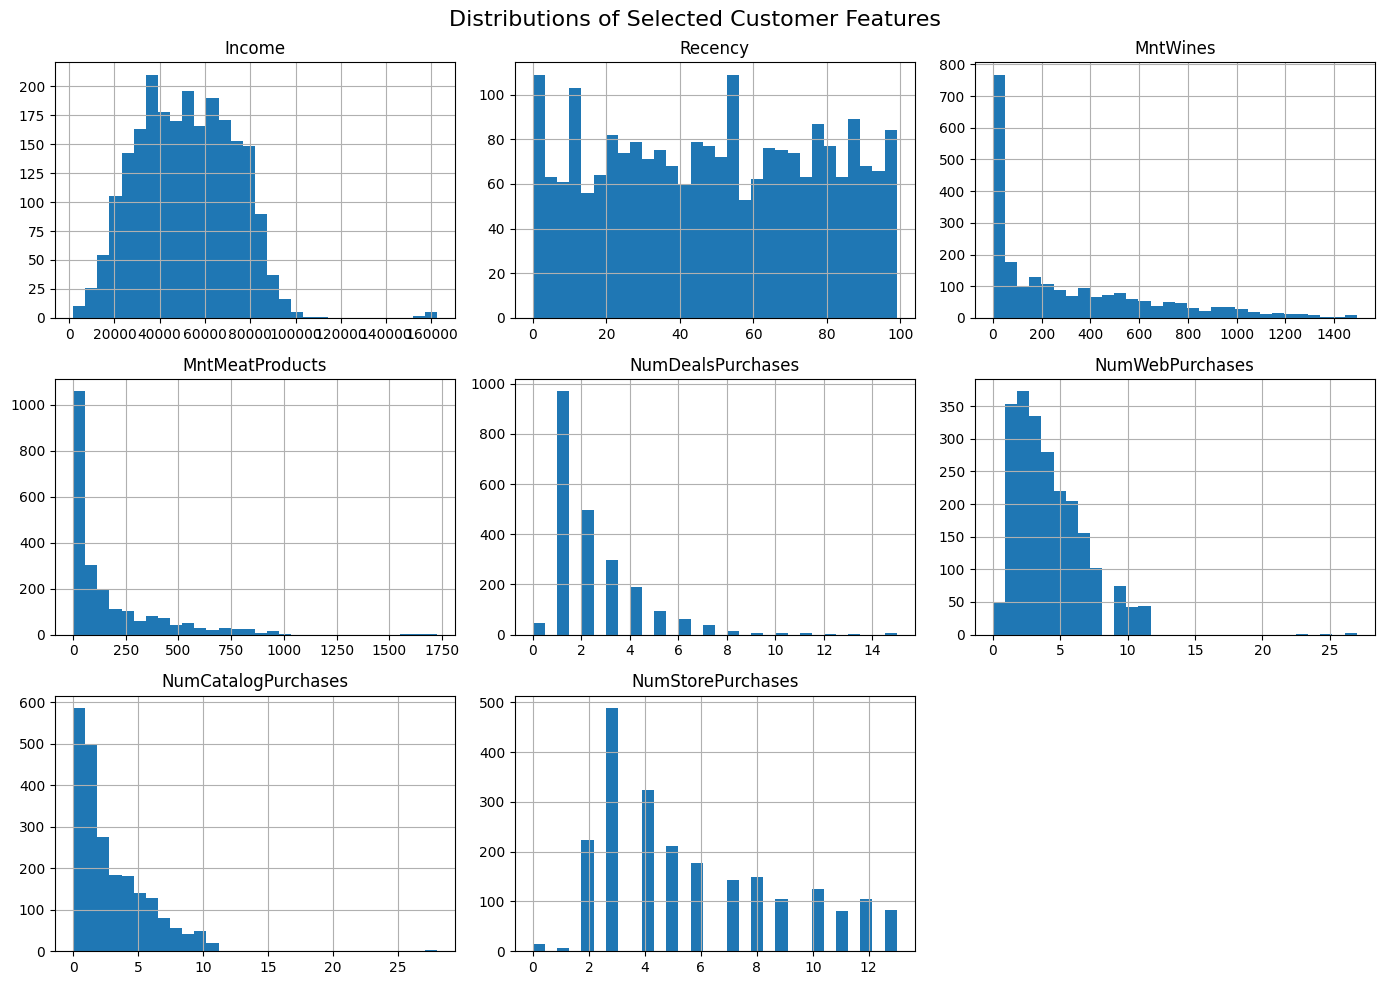

In [24]:
X.hist(figsize=(14, 10), bins=30)

plt.suptitle("Distributions of Selected Customer Features", fontsize=16)
plt.tight_layout()

plt.show()

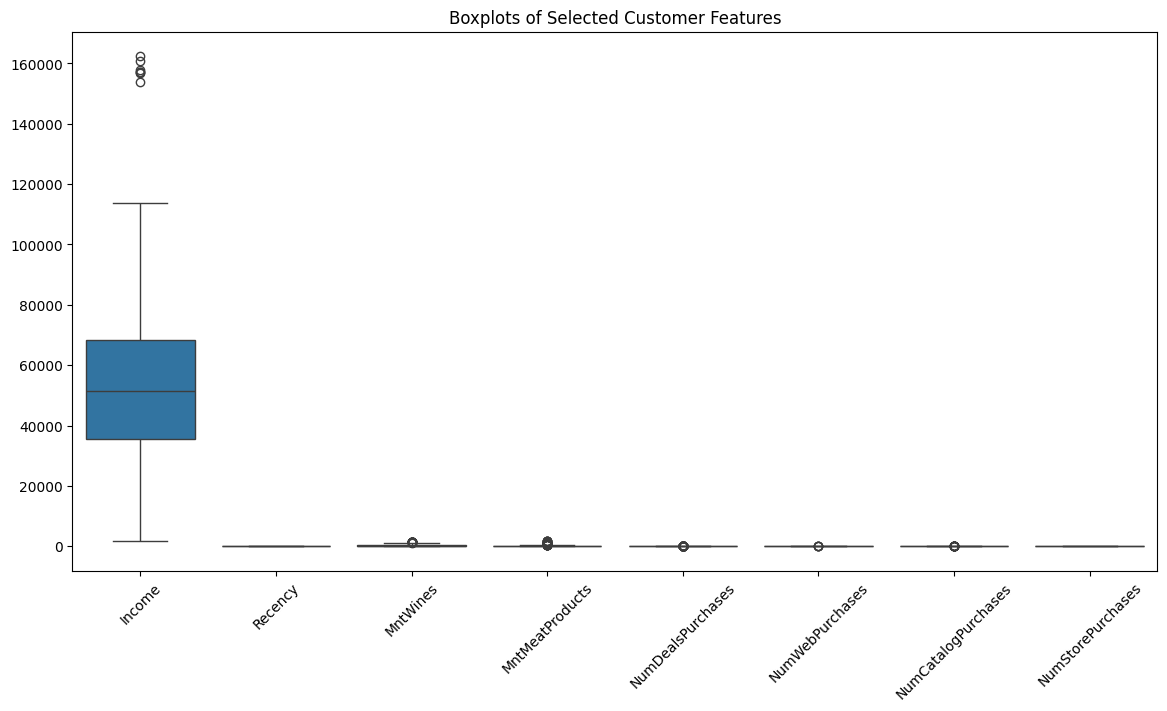

In [25]:
plt.figure(figsize=(14, 7))

sns.boxplot(data=X)

plt.title("Boxplots of Selected Customer Features")
plt.xticks(rotation=45)

plt.show()

some features had a much larger range (like income) than others, hence scaling is needed

In [26]:
#scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=features)

X_scaled.head()

,Income,Recency,MntWines,MntMeatProducts,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases
0,0.288446,0.306624,0.983339,1.679196,0.349782,1.408863,2.510257,-0.551136
1,-0.262524,-0.384051,-0.870826,-0.713430,-0.167840,-1.110374,-0.568888,-1.166440
2,0.917946,-0.798456,0.362313,-0.177305,-0.685461,1.408863,-0.226761,1.294778
3,-1.182738,-0.798456,-0.870826,-0.651399,-0.167840,-0.750483,-0.911015,-0.551136
4,0.295687,1.549838,-0.389456,-0.217182,1.385025,0.329190,0.115367,0.064169


In [27]:
display(X_scaled.describe())

,Income,Recency,MntWines,MntMeatProducts,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases
count,2.239000e+03,2.239000e+03,2.239000e+03,2.239000e+03,2.239000e+03,2.239000e+03,2.239000e+03,2.239000e+03
mean,-6.505639e-17,3.411494e-17,-4.125527e-17,2.221438e-17,-7.933706e-18,7.933706e-17,6.029617e-17,-8.489066e-17
std,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00
min,-2.346716e+00,-1.696333e+00,-9.035115e-01,-7.400151e-01,-1.203083e+00,-1.470265e+00,-9.110149e-01,-1.781745e+00
25%,-7.675483e-01,-8.675232e-01,-8.321975e-01,-6.691224e-01,-6.854614e-01,-7.504827e-01,-9.110149e-01,-8.587881e-01
50%,-2.719133e-02,-4.179831e-03,-3.864847e-01,-4.431522e-01,-1.678398e-01,-3.070084e-02,-2.267605e-01,-2.434836e-01
75%,7.621241e-01,8.591635e-01,5.955689e-01,2.879281e-01,3.497818e-01,6.890810e-01,4.574939e-01,6.794732e-01
max,5.159021e+00,1.722507e+00,3.532816e+00,6.903097e+00,6.561241e+00,8.246791e+00,8.668547e+00,2.217734e+00


In [28]:
#comparing before and after scaling
print("Before Scaling:")
display(X.describe())

print("\nAfter Scaling:")
display(X_scaled.describe())

Before Scaling:


,Income,Recency,MntWines,MntMeatProducts,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases
count,2239.000000,2239.000000,2239.000000,2239.000000,2239.000000,2239.000000,2239.000000,2239.000000
mean,51963.554712,49.121036,304.067441,167.016525,2.324252,4.085306,2.662796,5.791425
std,21410.672116,28.963662,336.614830,225.743829,1.932345,2.779240,2.923542,3.251149
min,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,35533.500000,24.000000,24.000000,16.000000,1.000000,2.000000,0.000000,3.000000
50%,51381.500000,49.000000,174.000000,67.000000,2.000000,4.000000,2.000000,5.000000
75%,68277.500000,74.000000,504.500000,232.000000,3.000000,6.000000,4.000000,8.000000
max,162397.000000,99.000000,1493.000000,1725.000000,15.000000,27.000000,28.000000,13.000000



After Scaling:


,Income,Recency,MntWines,MntMeatProducts,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases
count,2.239000e+03,2.239000e+03,2.239000e+03,2.239000e+03,2.239000e+03,2.239000e+03,2.239000e+03,2.239000e+03
mean,-6.505639e-17,3.411494e-17,-4.125527e-17,2.221438e-17,-7.933706e-18,7.933706e-17,6.029617e-17,-8.489066e-17
std,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00
min,-2.346716e+00,-1.696333e+00,-9.035115e-01,-7.400151e-01,-1.203083e+00,-1.470265e+00,-9.110149e-01,-1.781745e+00
25%,-7.675483e-01,-8.675232e-01,-8.321975e-01,-6.691224e-01,-6.854614e-01,-7.504827e-01,-9.110149e-01,-8.587881e-01
50%,-2.719133e-02,-4.179831e-03,-3.864847e-01,-4.431522e-01,-1.678398e-01,-3.070084e-02,-2.267605e-01,-2.434836e-01
75%,7.621241e-01,8.591635e-01,5.955689e-01,2.879281e-01,3.497818e-01,6.890810e-01,4.574939e-01,6.794732e-01
max,5.159021e+00,1.722507e+00,3.532816e+00,6.903097e+00,6.561241e+00,8.246791e+00,8.668547e+00,2.217734e+00


Scaling is important because KMeans and DBSCAN rely on distance calculations to determine similarity between data points. The selected features have very different numerical ranges. For example, Income and product spending amounts can be in the tens of thousands, while purchase counts and Recency have much smaller values. Without scaling, features with larger numerical ranges would dominate the distance calculations and disproportionately influence cluster formation. StandardScaler was therefore used to transform all selected numerical features to a comparable scale, with approximately zero mean and unit variance. This allows the clustering algorithms to consider each selected feature more fairly based on its variation rather than its original measurement scale.

# KMeans Clustering

In [29]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [31]:
# testing k values from 2 to 10.
k_values = range(2, 11)

inertia_values = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia_values.append(kmeans.inertia_)

for k, inertia in zip(k_values, inertia_values):
    print(f"K = {k}: Inertia = {inertia:.2f}")

K = 2: Inertia = 11087.58
K = 3: Inertia = 9305.04
K = 4: Inertia = 8474.33
K = 5: Inertia = 7662.63
K = 6: Inertia = 7205.40
K = 7: Inertia = 6778.02
K = 8: Inertia = 6420.78
K = 9: Inertia = 6098.67
K = 10: Inertia = 5848.28


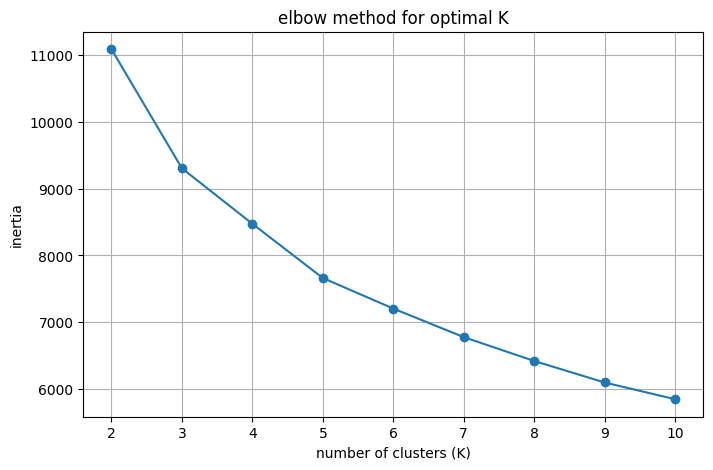

In [32]:
plt.figure(figsize=(8, 5))

plt.plot(k_values, inertia_values, marker="o")

plt.title("elbow method for optimal K")
plt.xlabel("number of clusters (K)")
plt.ylabel("inertia")

plt.xticks(k_values)
plt.grid(True)

plt.show()

In [33]:
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    cluster_labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(score)

    print(f"K = {k}: silhouette score = {score:.4f}")

K = 2: silhouette score = 0.3664
K = 3: silhouette score = 0.3083
K = 4: silhouette score = 0.2972
K = 5: silhouette score = 0.2216
K = 6: silhouette score = 0.2146
K = 7: silhouette score = 0.2187
K = 8: silhouette score = 0.2172
K = 9: silhouette score = 0.2135
K = 10: silhouette score = 0.2113


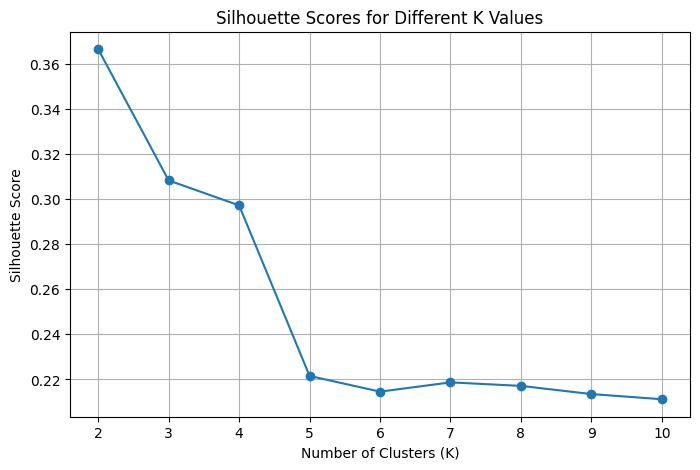

In [34]:
plt.figure(figsize=(8, 5))

plt.plot(k_values, silhouette_scores, marker="o")

plt.title("Silhouette Scores for Different K Values")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")

plt.xticks(k_values)
plt.grid(True)

plt.show()

In [35]:
kmeans_results = pd.DataFrame({
    "K": list(k_values),
    "Inertia": inertia_values,
    "Silhouette Score": silhouette_scores
})

display(kmeans_results)

,K,Inertia,Silhouette Score
0,2,11087.576649,0.366419
1,3,9305.040607,0.308250
2,4,8474.327873,0.297177
3,5,7662.627466,0.221575
4,6,7205.398805,0.214607
5,7,6778.015988,0.218724
6,8,6420.781090,0.217164
7,9,6098.668378,0.213538
8,10,5848.276064,0.211252


In [36]:
final_k = 2  # should be replace with the selected K. in my case best K is 2

kmeans_final = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans_final.fit_predict(X_scaled)

In [37]:
clustered_data = X.copy()

clustered_data["Cluster"] = kmeans_labels

clustered_data.head()

,Income,Recency,MntWines,MntMeatProducts,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,Cluster
0,58138.0,58,635,546,3,8,10,4,1
1,46344.0,38,11,6,2,1,1,2,0
2,71613.0,26,426,127,1,8,2,10,1
3,26646.0,26,11,20,2,2,0,4,0
4,58293.0,94,173,118,5,5,3,6,0


In [38]:
cluster_counts = clustered_data["Cluster"].value_counts().sort_index()

print("Number of Customers in Each Cluster:")
print(cluster_counts)

Number of Customers in Each Cluster:
Cluster
0    1209
1    1030
Name: count, dtype: int64


In [39]:
cluster_summary = clustered_data.groupby("Cluster")[features].agg(
    ["count", "mean", "median", "min", "max"]
)

display(cluster_summary)

Income                                          Recency             \
         count          mean   median     min       max   count       mean   
Cluster                                                                      
0         1209  36724.925145  36736.0  1730.0  156924.0    1209  48.910670   
1         1030  69850.450971  69573.5  2447.0  162397.0    1030  49.367961   

                        ... NumCatalogPurchases                           \
        median min max  ...               count      mean median min max   
Cluster                 ...                                                
0         49.0   0  99  ...                1209  0.727047    1.0   0   8   
1         51.0   0  99  ...                1030  4.934951    4.0   0  28   

        NumStorePurchases                           
                    count      mean median min max  
Cluster                                             
0                    1209  3.555004    3.0   0   9  
1                    1030  8.416505    8.0   0  13  

[2 rows x 40 columns]

In [40]:
cluster_means = clustered_data.groupby("Cluster")[features].mean()

display(cluster_means)

,Income,Recency,MntWines,MntMeatProducts,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases
Cluster,,,,,,,,
0,36724.925145,48.910670,62.676592,31.264682,2.266336,2.561621,0.727047,3.555004
1,69850.450971,49.367961,587.408738,326.360194,2.392233,5.873786,4.934951,8.416505


**Interpretation:**

Cluster 0 is characterized by lower income, lower spending, and lower purchasing activity across web, catalog, and store channels. Cluster 1 is characterized by higher income, substantially higher spending on wine and meat products, and greater purchasing activity across all channels. The main separation between the clusters is therefore related to customer income, spending level, and purchasing activity rather than recency.

# PCA

In [41]:
from sklearn.decomposition import PCA

pca_full = PCA()

X_pca_full = pca_full.fit_transform(X_scaled)

explained_variance_ratio = pca_full.explained_variance_ratio_

for i, variance in enumerate(explained_variance_ratio, start=1):
    print(f"PC{i}: {variance:.4f} ({variance * 100:.2f}%)")

PC1: 0.4798 (47.98%)
PC2: 0.1512 (15.12%)
PC3: 0.1250 (12.50%)
PC4: 0.0815 (8.15%)
PC5: 0.0562 (5.62%)
PC6: 0.0410 (4.10%)
PC7: 0.0333 (3.33%)
PC8: 0.0319 (3.19%)


i do cumulative explained variance to see how much of the original data's information is retained as i add more principal components. cumulative variance lets me directly see how much information PC1 + PC2 together have

In [42]:
cumulative_variance = np.cumsum(explained_variance_ratio)

for i, variance in enumerate(cumulative_variance, start=1):
    print(f"First {i} component(s): {variance * 100:.2f}% cumulative variance")

First 1 component(s): 47.98% cumulative variance
First 2 component(s): 63.11% cumulative variance
First 3 component(s): 75.61% cumulative variance
First 4 component(s): 83.76% cumulative variance
First 5 component(s): 89.38% cumulative variance
First 6 component(s): 93.48% cumulative variance
First 7 component(s): 96.81% cumulative variance
First 8 component(s): 100.00% cumulative variance


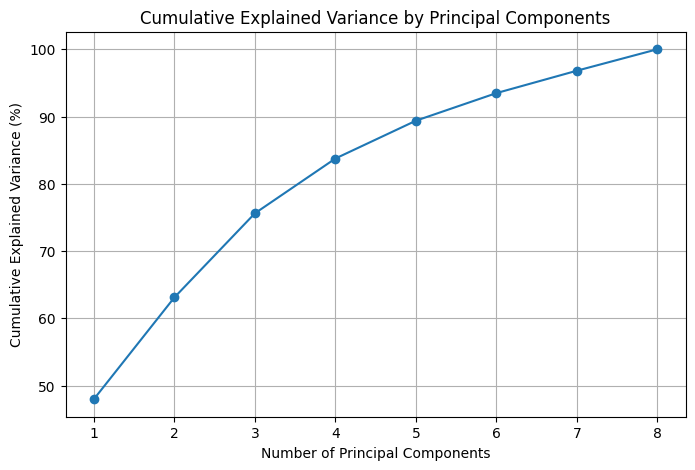

In [43]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(explained_variance_ratio) + 1),
    cumulative_variance * 100,
    marker="o"
)

plt.title("Cumulative Explained Variance by Principal Components")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance (%)")
plt.xticks(range(1, len(explained_variance_ratio) + 1))
plt.grid(True)

plt.show()

In [44]:
#PCA to 2 components
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("\nPC1 explains:", round(pca.explained_variance_ratio_[0] * 100, 2), "%")
print("PC2 explains:", round(pca.explained_variance_ratio_[1] * 100, 2), "%")

print("\nTotal variance explained by first 2 components:",
      round(sum(pca.explained_variance_ratio_) * 100, 2), "%")

Explained Variance Ratio:
[0.47983248 0.15122154]

PC1 explains: 47.98 %
PC2 explains: 15.12 %

Total variance explained by first 2 components: 63.11 %


**How much variance did the first two PCA components explain?**

Total variance explained by first 2 components: 63.11 %

In [45]:
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = kmeans_labels

pca_df.head()

,PC1,PC2,Cluster
0,2.544786,0.049755,1
1,-1.858646,-0.523642,0
2,1.365699,0.303174,1
3,-2.031163,-0.078547,0
4,0.074199,1.142284,0


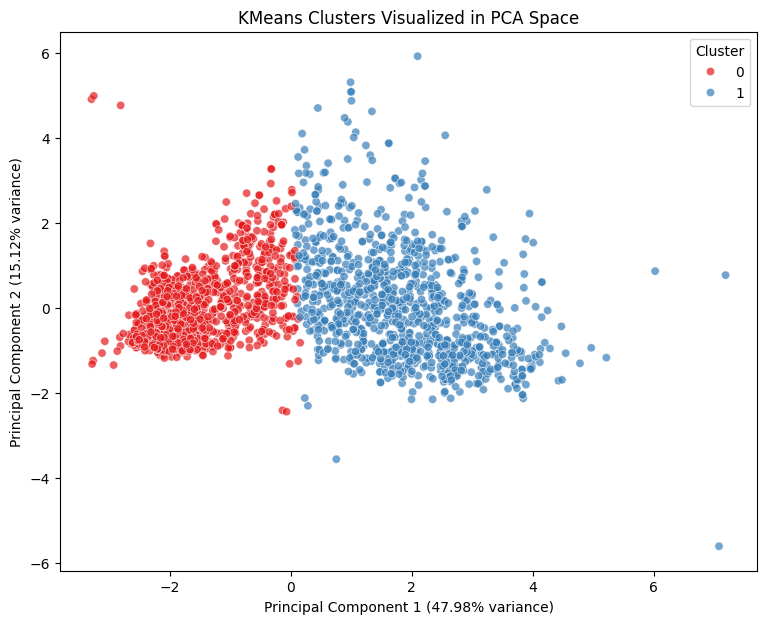

In [46]:
plt.figure(figsize=(9, 7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set1",
    alpha=0.7
)

plt.title("KMeans Clusters Visualized in PCA Space")
plt.xlabel(
    f"Principal Component 1 ({pca.explained_variance_ratio_[0] * 100:.2f}% variance)"
)
plt.ylabel(
    f"Principal Component 2 ({pca.explained_variance_ratio_[1] * 100:.2f}% variance)"
)

plt.legend(title="Cluster")
plt.show()

PC1 explained 47.98% of the total variance, while PC2 explained 15.12%. Together, the first two principal components explained 63.11% of the total variance in the scaled dataset. So the 2D PCA visualization retained 63.11% of the original variation. PC1 is doing most of the work in separating the data.

But ~36.89% of the variance was not represented in the 2D plot, so the PCA visualization is only a projection and may not preserve every structure or separation present in the original 8D feature space.